# DINO pipeline — eval metrics and plots

Run the repo’s DINO detection + classifier on every image listed in `eval_data/labels.jsonl`, then score predictions with `yolo.yolo.parse_json` and `classification_accuracy` (set-based global precision / recall / F1 and per-image breakdown).

**Setup:** open this notebook from the `cv-final` repo root (so `dino_pipeline.py` is in the working directory), or adjust `REPO_ROOT` below.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "dino_pipeline.py").exists():
    raise RuntimeError(f"Run from cv-final root; cwd={REPO_ROOT}")

from dino_detect import load_model as load_detector
from dino_pipeline import detect_and_classify, load_classifier
from yolo.yolo import classification_accuracy, parse_json

LABELS_JSONL = REPO_ROOT / "eval_data" / "labels.jsonl"
DEVICE = "cuda" if __import__("torch").cuda.is_available() else "cpu"

# Match CLI defaults in dino_pipeline.py
PIPELINE_KWARGS = dict(
    method="tokencut",
    device=DEVICE,
)

print("REPO_ROOT:", REPO_ROOT)
print("DEVICE:", DEVICE)

/oscar/data/class/csci1430/students/sli347/cv-final/.venv/lib64/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


REPO_ROOT: /oscar/data/class/csci1430/students/sli347/cv-final
DEVICE: cuda


In [2]:
def load_eval_rows(jsonl_path: Path) -> list[dict]:
    rows = []
    with open(jsonl_path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rows.append(json.loads(line))
    return rows


def run_dino_on_eval_jsonl(jsonl_path: Path, **pipeline_kw):
    """Return pred_ingredients dict basename -> [{"ingredient": str}, ...]."""
    detector = load_detector(pipeline_kw["device"])
    backbone, classifier, processor, class_names = load_classifier(pipeline_kw["device"])
    pred_ingredients: dict[str, list[dict]] = {}
    for row in load_eval_rows(jsonl_path):
        rel = Path(row["image"])
        image_path = REPO_ROOT / rel
        name = rel.name
        if not image_path.is_file():
            print(f"skip missing: {image_path}")
            continue
        image = Image.open(image_path).convert("RGB")
        detections, _ = detect_and_classify(
            image,
            detector,
            backbone,
            classifier,
            processor,
            class_names,
            **pipeline_kw,
        )
        pred_ingredients[name] = [{"ingredient": d.ingredient} for d in detections]
    return pred_ingredients


actual_ingredients = parse_json(LABELS_JSONL)
pred_ingredients = run_dino_on_eval_jsonl(LABELS_JSONL, **PIPELINE_KWARGS)
metrics = classification_accuracy(pred_ingredients, actual_ingredients)

summary = metrics["summary"]
per_image = metrics["per_image"]
print("Summary:", summary)

/oscar/data/class/csci1430/students/sli347/cv-final/.venv/lib64/python3.9/site-packages/peft/config.py:165: UserWarning: Unexpected keyword arguments ['alora_invocation_tokens', 'arrow_config', 'ensure_weight_tying', 'lora_ga_config', 'peft_version', 'use_bdlora'] for class LoraConfig, these are ignored. This probably means that you're loading a configuration file that was saved using a higher version of the library and additional parameters have been introduced since. It is highly recommended to upgrade the PEFT version before continuing (e.g. by running `pip install -U peft`).
  warnings.warn(
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Predicted set: {'sponge gourd', 'noodles', 'lemon', 'avocado', 'carrot', 'chili pepper', 'banana', 'ham', 'turnip'}
True set: {'avocado', 'banana', 'broccoli', 'ham', 'tomato', 'cheese'}
Predicted set: {'buffalo meat', 'fiddlehead ferns', 'sponge gourd', 'potato', 'carrot', 'cabbage', 'chili pepper', 'egg', 'butter', 'bitter gourd'}
True set: {'red cabbage', 'cabbage', 'carrot', 'cucumber', 'parsley', 'cauliflower', 'tomato', 'kale', 'egg', 'red onion'}
Predicted set: {'sponge gourd', 'olive oil', 'pork', 'onion', 'lime', 'snake gourd', 'coriander', 'green lentils', 'egg', 'turnip', 'bitter gourd'}
True set: {'cherry tomato', 'apple', 'carrot', 'bread', 'yogurt', 'lettuce', 'milk', 'tomato', 'egg', 'cucumber', 'bell pepper'}
Predicted set: {'sponge gourd', 'potato', 'eggplant', 'carrot', 'cabbage', 'olive oil', 'radish', 'soy chunks', 'ham', 'green lentils', 'egg', 'bitter gourd'}
True set: {'egg', 'avocado', 'carrot', 'grape', 'scallion', 'almond milk', 'blueberry', 'bread', 'lettuce'

In [3]:
df_img = pd.DataFrame.from_dict(per_image, orient="index")
df_img.index.name = "image"
df_img = df_img.reset_index()
df_img = df_img.sort_values("f1")

display(df_img)

df_summary = pd.DataFrame([summary])
display(df_summary)

,image,tp,fp,fn,precision,recall,f1
7,photo-1606859191214-25806e8e2423.jpg,0,0,13,0.0000,0.0000,0.0000
8,photo-1622001545761-9bd12a4b465b.jpg,0,4,4,0.0000,0.0000,0.0000
18,photo-1775203304348-bc115948e718.jpg,0,11,7,0.0000,0.0000,0.0000
2,fridge_test3.jpg,1,10,10,0.0909,0.0909,0.0909
21,premium_photo-1701006579559-49cf5d1a0b7a.jpg,1,9,9,0.1000,0.1000,0.1000
27,premium_photo-1734646975674-64764e7dc70d.jpg,1,8,8,0.1111,0.1111,0.1111
15,photo-1737363625921-dd9e02b4c067.jpg,1,7,6,0.1250,0.1429,0.1333
14,photo-1737363625030-164e39339156.jpg,1,4,7,0.2000,0.1250,0.1538
13,photo-1710947949965-8150d227d337.jpg,1,8,3,0.1111,0.2500,0.1538
3,fridge_test4.jpg,2,10,11,0.1667,0.1538,0.1600


,global_precision,global_recall,global_f1,images_evaluated
0,0.2801,0.2548,0.2669,33


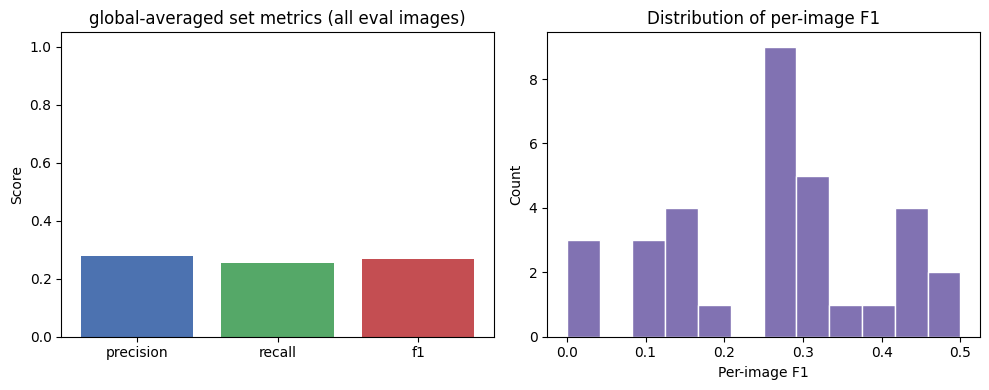

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ax = axes[0]
keys = ["global_precision", "global_recall", "global_f1"]
vals = [summary[k] for k in keys]
ax.bar([k.replace("global_", "") for k in keys], vals, color=["#4C72B0", "#55A868", "#C44E52"])
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("global-averaged set metrics (all eval images)")

ax = axes[1]
ax.hist(df_img["f1"], bins=12, color="#8172B2", edgecolor="white")
ax.set_xlabel("Per-image F1")
ax.set_ylabel("Count")
ax.set_title("Distribution of per-image F1")

plt.tight_layout()
plt.show()

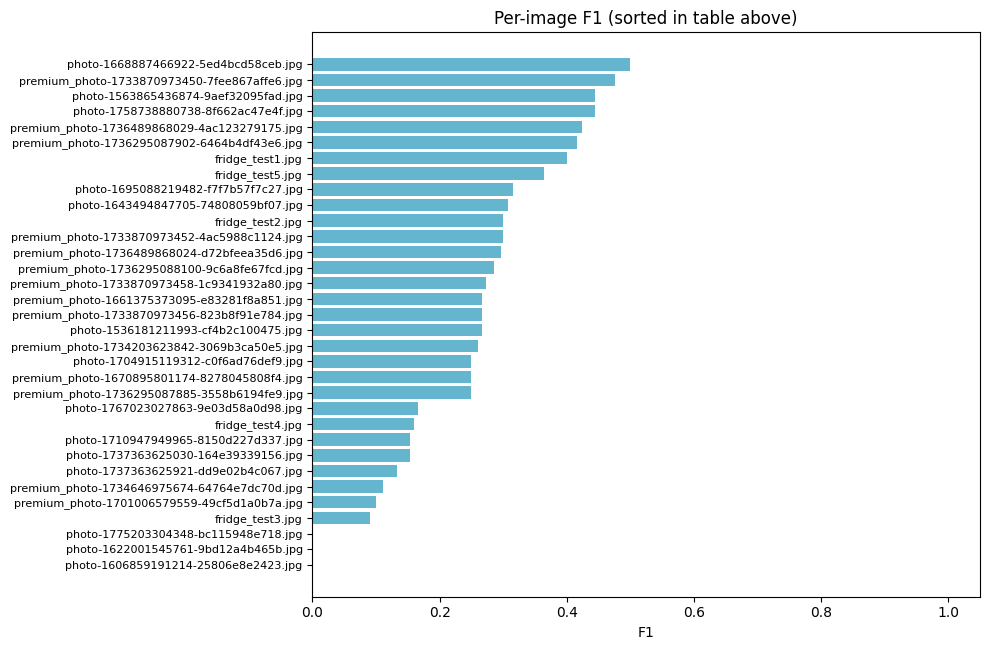

In [5]:
fig, ax = plt.subplots(figsize=(10, max(4, 0.2 * len(df_img))))
y = np.arange(len(df_img))
ax.barh(y, df_img["f1"].values, color="#64B5CD")
ax.set_yticks(y)
ax.set_yticklabels(df_img["image"].values, fontsize=8)
ax.set_xlabel("F1")
ax.set_title("Per-image F1 (sorted in table above)")
ax.set_xlim(0, 1.05)
plt.tight_layout()
plt.show()

## 